In [1]:
# basic imports

import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0


In [2]:
# keep the runs consistent

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [3]:
# dataset settings

batch_size = 128
num_workers = 0

num_classes = 10

image_size = 32

print("Batch size:", batch_size)
print("Number of classes:", num_classes)

Batch size: 128
Number of classes: 10


In [4]:
# load CIFAR-10

data_root = "../data"

base_transform = transforms.ToTensor()

full_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=base_transform
)

test_dataset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=base_transform
)

print("Training samples:", len(full_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


In [5]:
# split the training data

train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 45000
Validation samples: 5000


In [6]:
# define the different augmentation choices

transform_options = {

    "No Augmentation": transforms.Compose([
        transforms.ToTensor()
    ]),

    "Rotation": transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ]),

    "Random Crop": transforms.Compose([
        transforms.RandomCrop(
            32,
            padding=4
        ),
        transforms.ToTensor()
    ]),

    "Color Jitter": transforms.Compose([
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor()
    ]),

    "Rotation + Crop": transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomCrop(
            32,
            padding=4
        ),
        transforms.ToTensor()
    ]),

    "Rotation + Crop + Color Jitter": transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomCrop(
            32,
            padding=4
        ),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor()
    ])
}

print("Experiments:", len(transform_options))

for name in transform_options:
    print("-", name)

Experiments: 6
- No Augmentation
- Rotation
- Random Crop
- Color Jitter
- Rotation + Crop
- Rotation + Crop + Color Jitter


In [7]:
# prepare a train and validation dataset for each experiment

experiment_datasets = {}

for experiment_name, transform in transform_options.items():

    train_full = datasets.CIFAR10(
        root=data_root,
        train=True,
        download=False,
        transform=transform
    )

    val_full = datasets.CIFAR10(
        root=data_root,
        train=True,
        download=False,
        transform=transforms.ToTensor()
    )

    train_subset = torch.utils.data.Subset(
        train_full,
        train_indices.indices
    )

    val_subset = torch.utils.data.Subset(
        val_full,
        val_indices.indices
    )

    experiment_datasets[experiment_name] = (
        train_subset,
        val_subset
    )

print("Datasets prepared for all experiments.")

Datasets prepared for all experiments.


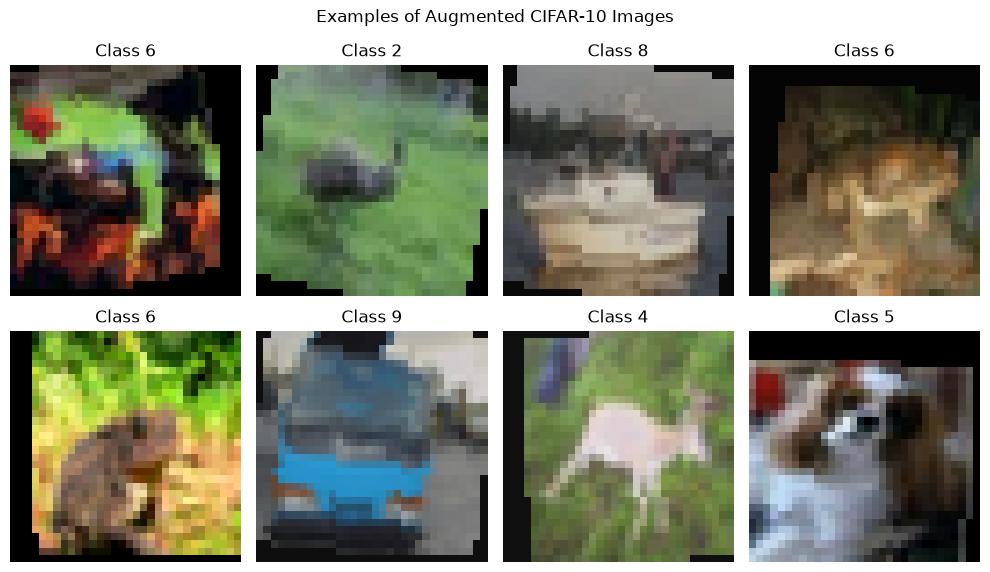

In [8]:
# have a quick look at the augmented images

sample_name = "Rotation + Crop + Color Jitter"

sample_dataset = experiment_datasets[sample_name][0]

plt.figure(figsize=(10, 6))

for i in range(8):

    image, label = sample_dataset[i]

    plt.subplot(2, 4, i + 1)

    image_display = image.permute(1, 2, 0)

    plt.imshow(image_display)
    plt.title(f"Class {label}")
    plt.axis("off")

plt.suptitle("Examples of Augmented CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [9]:
# use the same custom CNN for every experiment

class CustomCNN(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.30),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.35)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


# check the model

model_check = CustomCNN(num_classes).to(device)

print(model_check)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil

In [10]:
# training settings

epochs = 5

learning_rate = 0.001

weight_decay = 1e-4

print("Epochs:", epochs)
print("Learning rate:", learning_rate)
print("Weight decay:", weight_decay)

Epochs: 5
Learning rate: 0.001
Weight decay: 0.0001


In [11]:
# train one experiment

def train_one_experiment(
    experiment_name,
    train_dataset,
    val_dataset
):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    model = CustomCNN(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_accuracy = 0.0

    best_state = copy.deepcopy(
        model.state_dict()
    )

    start_time = time.perf_counter()

    for epoch in range(epochs):

        # training

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total

        train_accuracy = correct / total

        # validation

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += (
                    loss.item() * labels.size(0)
                )

                predictions = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss = val_running_loss / val_total

        val_accuracy = val_correct / val_total

        scheduler.step(val_accuracy)

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"{experiment_name} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    training_time = (
        time.perf_counter() - start_time
    )

    model.load_state_dict(best_state)

    return (
        model,
        history,
        best_val_accuracy,
        training_time
    )

In [12]:
# start with the baseline

results = []
histories = {}
trained_models = {}

experiment_name = "No Augmentation"

train_dataset, val_dataset = (
    experiment_datasets[experiment_name]
)

model, history, best_accuracy, training_time = (
    train_one_experiment(
        experiment_name,
        train_dataset,
        val_dataset
    )
)

histories[experiment_name] = history
trained_models[experiment_name] = model

results.append({
    "Experiment": experiment_name,
    "Best Validation Accuracy": best_accuracy,
    "Final Train Accuracy": history["train_accuracy"][-1],
    "Final Validation Accuracy": history["val_accuracy"][-1],
    "Final Train Loss": history["train_loss"][-1],
    "Final Validation Loss": history["val_loss"][-1],
    "Training Time (s)": training_time
})

print("\nBaseline finished.")

No Augmentation | Epoch 1/5 | Train Acc: 0.4468 | Val Acc: 0.5960
No Augmentation | Epoch 2/5 | Train Acc: 0.6013 | Val Acc: 0.6290
No Augmentation | Epoch 3/5 | Train Acc: 0.6507 | Val Acc: 0.6488
No Augmentation | Epoch 4/5 | Train Acc: 0.6807 | Val Acc: 0.7230
No Augmentation | Epoch 5/5 | Train Acc: 0.7064 | Val Acc: 0.7432

Baseline finished.


In [13]:
# run the remaining augmentation experiments

for experiment_name in list(transform_options.keys())[1:]:

    print("\n" + "=" * 60)
    print("Running:", experiment_name)
    print("=" * 60)

    train_dataset, val_dataset = (
        experiment_datasets[experiment_name]
    )

    model, history, best_accuracy, training_time = (
        train_one_experiment(
            experiment_name,
            train_dataset,
            val_dataset
        )
    )

    histories[experiment_name] = history

    trained_models[experiment_name] = model

    results.append({
        "Experiment": experiment_name,
        "Best Validation Accuracy": best_accuracy,
        "Final Train Accuracy": history["train_accuracy"][-1],
        "Final Validation Accuracy": history["val_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Validation Loss": history["val_loss"][-1],
        "Training Time (s)": training_time
    })

print("\nAll augmentation experiments completed.")


Running: Rotation
Rotation | Epoch 1/5 | Train Acc: 0.4140 | Val Acc: 0.5604
Rotation | Epoch 2/5 | Train Acc: 0.5422 | Val Acc: 0.6146
Rotation | Epoch 3/5 | Train Acc: 0.6002 | Val Acc: 0.6280
Rotation | Epoch 4/5 | Train Acc: 0.6302 | Val Acc: 0.7096
Rotation | Epoch 5/5 | Train Acc: 0.6558 | Val Acc: 0.6936

Running: Random Crop
Random Crop | Epoch 1/5 | Train Acc: 0.3957 | Val Acc: 0.5318
Random Crop | Epoch 2/5 | Train Acc: 0.5322 | Val Acc: 0.5334
Random Crop | Epoch 3/5 | Train Acc: 0.5866 | Val Acc: 0.6414
Random Crop | Epoch 4/5 | Train Acc: 0.6148 | Val Acc: 0.6592
Random Crop | Epoch 5/5 | Train Acc: 0.6443 | Val Acc: 0.6822

Running: Color Jitter
Color Jitter | Epoch 1/5 | Train Acc: 0.4257 | Val Acc: 0.5832
Color Jitter | Epoch 2/5 | Train Acc: 0.5814 | Val Acc: 0.6280
Color Jitter | Epoch 3/5 | Train Acc: 0.6388 | Val Acc: 0.7000
Color Jitter | Epoch 4/5 | Train Acc: 0.6732 | Val Acc: 0.7002
Color Jitter | Epoch 5/5 | Train Acc: 0.6951 | Val Acc: 0.7210

Running: Rotati

In [14]:
# put all runs into one table

results_df = pd.DataFrame(results)

results_df["Overfitting Gap"] = (
    results_df["Final Train Accuracy"]
    - results_df["Final Validation Accuracy"]
)

results_df = results_df.sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Experiment,Best Validation Accuracy,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss,Training Time (s),Overfitting Gap
0,No Augmentation,0.7432,0.706422,0.7432,0.837501,0.709895,45.589193,-0.036778
1,Color Jitter,0.7210,0.695089,0.7210,0.870270,0.779636,78.495409,-0.025911
2,Rotation,0.7096,0.655778,0.6936,0.977700,0.896061,50.921247,-0.037822
3,Random Crop,0.6822,0.644289,0.6822,1.008894,0.879763,59.342181,-0.037911
4,Rotation + Crop,0.6574,0.596778,0.6574,1.131493,0.951538,57.019686,-0.060622
5,Rotation + Crop + Color Jitter,0.6338,0.569200,0.6338,1.206659,1.008083,69.070607,-0.064600


In [15]:
# save the experiment results

results_path = "../results/day12_augmentation_experiments.csv"

results_df.to_csv(
    results_path,
    index=False
)

print("Experiment log saved to:")
print(results_path)

Experiment log saved to:
../results/day12_augmentation_experiments.csv


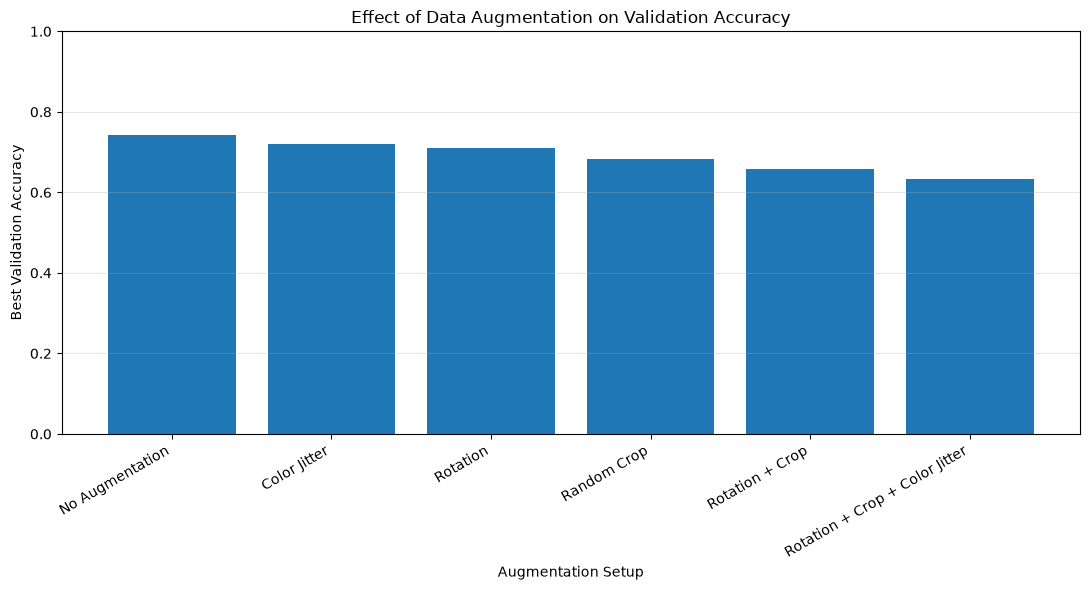

In [16]:
# compare the six experiments

plt.figure(figsize=(11, 6))

plt.bar(
    results_df["Experiment"],
    results_df["Best Validation Accuracy"]
)

plt.ylabel("Best Validation Accuracy")
plt.xlabel("Augmentation Setup")
plt.title("Effect of Data Augmentation on Validation Accuracy")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

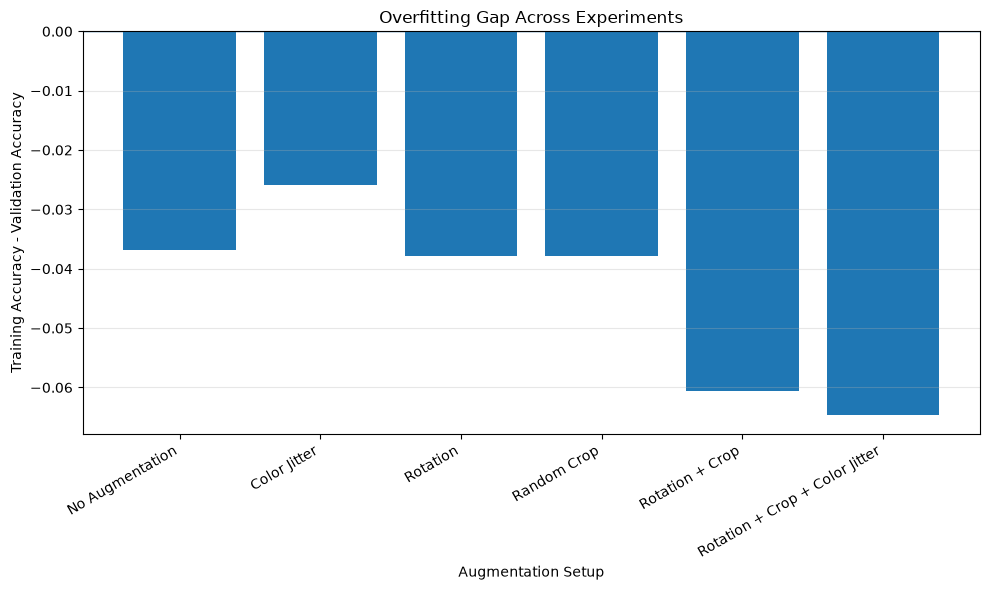

In [17]:
# check how large the train-validation gap is

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Experiment"],
    results_df["Overfitting Gap"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Training Accuracy - Validation Accuracy")
plt.xlabel("Augmentation Setup")
plt.title("Overfitting Gap Across Experiments")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

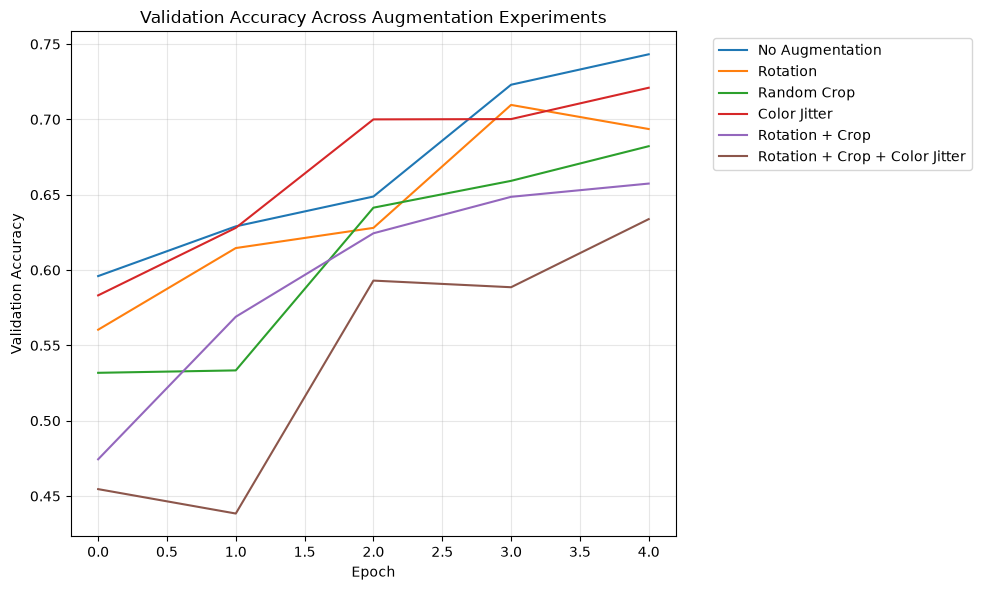

In [18]:
# compare the learning curves

plt.figure(figsize=(10, 6))

for experiment_name, history in histories.items():

    plt.plot(
        history["val_accuracy"],
        label=experiment_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Augmentation Experiments")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

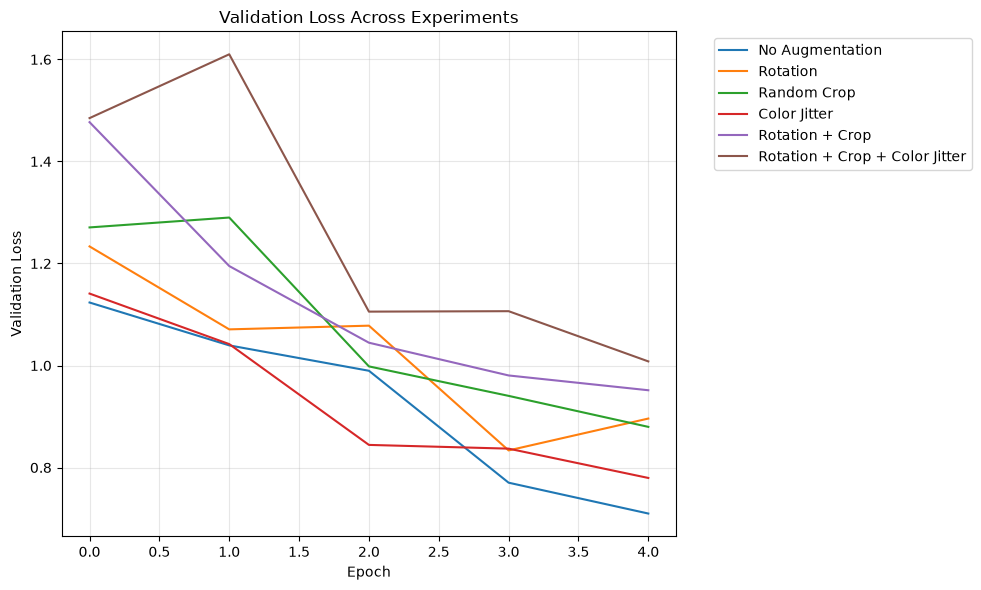

In [19]:
# look at validation loss

plt.figure(figsize=(10, 6))

for experiment_name, history in histories.items():

    plt.plot(
        history["val_loss"],
        label=experiment_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Experiments")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# find the best augmentation setup

best_row = results_df.iloc[0]

best_experiment = best_row["Experiment"]
best_accuracy = best_row["Best Validation Accuracy"]

print("=" * 55)
print("BEST AUGMENTATION SETUP")
print("=" * 55)

print("Experiment:", best_experiment)
print(
    f"Best validation accuracy: {best_accuracy:.4f}"
)

print(
    f"Training accuracy: "
    f"{best_row['Final Train Accuracy']:.4f}"
)

print(
    f"Validation accuracy: "
    f"{best_row['Final Validation Accuracy']:.4f}"
)

print(
    f"Overfitting gap: "
    f"{best_row['Overfitting Gap']:.4f}"
)

print(
    f"Training time: "
    f"{best_row['Training Time (s)']:.2f} seconds"
)

BEST AUGMENTATION SETUP
Experiment: No Augmentation
Best validation accuracy: 0.7432
Training accuracy: 0.7064
Validation accuracy: 0.7432
Overfitting gap: -0.0368
Training time: 45.59 seconds


In [21]:
# save the best experiment

best_model_path = "../results/day12_best_augmented_cnn.pth"

torch.save(
    {
        "model_state_dict":
            trained_models[best_experiment].state_dict(),

        "experiment":
            best_experiment,

        "best_validation_accuracy":
            float(best_accuracy),

        "architecture":
            "CustomCNN",

        "augmentation":
            best_experiment
    },
    best_model_path
)

print("Best model saved to:")
print(best_model_path)

Best model saved to:
../results/day12_best_augmented_cnn.pth


In [22]:
# final summary

print("=" * 60)
print("DAY 12 RESULTS")
print("=" * 60)

print(
    f"Experiments completed : {len(results_df)}"
)

print(
    f"Best setup            : {best_experiment}"
)

print(
    f"Best validation acc.  : {best_accuracy:.4f}"
)

print(
    f"Results saved to      : {results_path}"
)

print(
    f"Best model saved to   : {best_model_path}"
)

print("\nAugmentation methods tested:")
print("- Rotation")
print("- Random crop")
print("- Color jitter")
print("- Rotation + crop")
print("- Rotation + crop + color jitter")

print(
    "\nThe experiments were used to compare "
    "different augmentation strategies and "
    "observe their effect on validation performance "
    "and overfitting."
)

DAY 12 RESULTS
Experiments completed : 6
Best setup            : No Augmentation
Best validation acc.  : 0.7432
Results saved to      : ../results/day12_augmentation_experiments.csv
Best model saved to   : ../results/day12_best_augmented_cnn.pth

Augmentation methods tested:
- Rotation
- Random crop
- Color jitter
- Rotation + crop
- Rotation + crop + color jitter

The experiments were used to compare different augmentation strategies and observe their effect on validation performance and overfitting.
